## Importing data and libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
train_identity = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_identity.csv")
train_transaction = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_transaction.csv")
x_train = train_identity.merge(train_transaction, how="left", on="TransactionID")


## Visualizing transaction amount

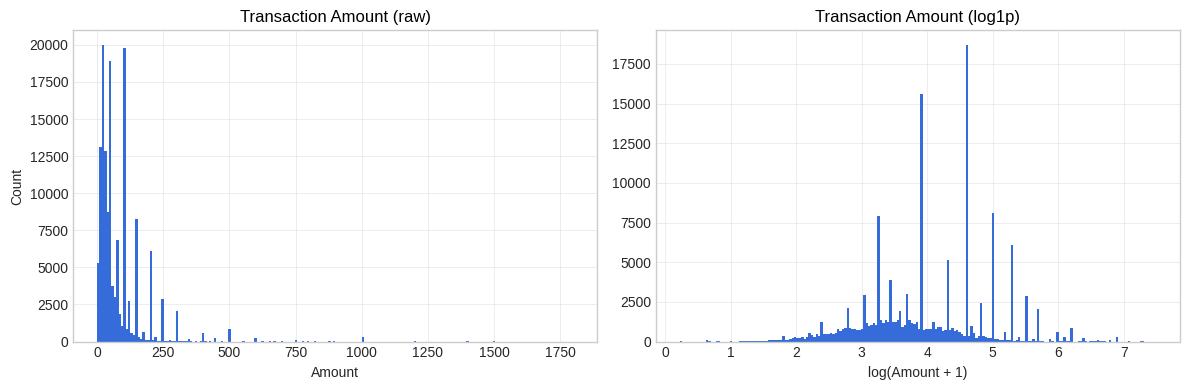

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_train['TransactionAmt'], bins=200)
axes[0].set_title('Transaction Amount (raw)', color='black')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(x_train['TransactionAmt']), bins=200)
axes[1].set_title('Transaction Amount (log1p)', color='black')
axes[1].set_xlabel('log(Amount + 1)')
plt.tight_layout()
fig.savefig('transaction_distribution.png', bbox_inches='tight')
plt.show()


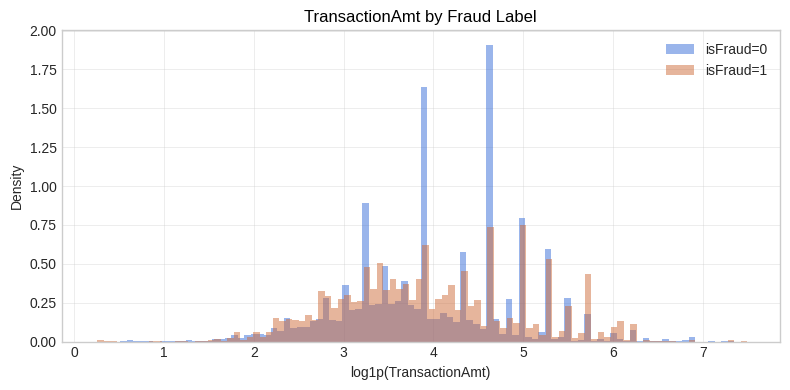

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in x_train.groupby('isFraud'):
    ax.hist(np.log1p(group['TransactionAmt']), bins=100, alpha=0.5, label=f'isFraud={label}', density=True)
ax.set_xlabel('log1p(TransactionAmt)')
ax.set_ylabel('Density')
ax.set_title('TransactionAmt by Fraud Label', color='black')
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
x_train['TransactionAmt'] = np.log1p(x_train['TransactionAmt'])


## Visualizing imbalanced data

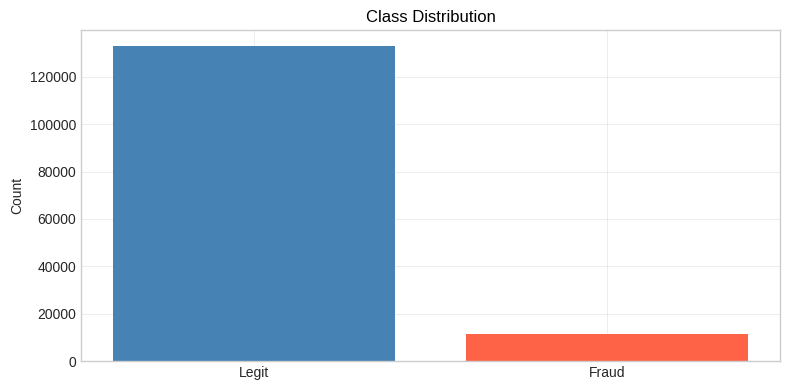

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = x_train.groupby('isFraud')['TransactionID'].count()
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution', color='black')
plt.tight_layout()
fig.savefig('class_distribution.png', bbox_inches='tight')
plt.show()


## Handling missing values

In [7]:
def na_to_cols(df, threshold=0.6):
    cols_to_transform = df.columns[df.isna().mean() > threshold]
    nan_flags = pd.concat(
        [df[col].isnull().astype(int).rename(col + '_isNaN') for col in cols_to_transform],
        axis=1
    )
    df = pd.concat([df, nan_flags], axis=1)
    df = df.drop(columns=cols_to_transform)
    return df

df_clean = na_to_cols(x_train, threshold=0.6)
df_clean = na_to_cols(df_clean, threshold=0.17)


In [8]:
y = df_clean['isFraud'].astype(int)
df_clean = df_clean.drop(columns=['isFraud'])


## Imputing missing values

In [9]:
num_cols = df_clean.select_dtypes(exclude='str').columns.tolist()
cat_cols = df_clean.select_dtypes(include='str').columns.tolist()

imputer = ColumnTransformer([
    ("num", SimpleImputer(strategy='mean'), num_cols),
    ("cat", SimpleImputer(strategy='most_frequent'), cat_cols)
]).set_output(transform="pandas")

df_clean_t = imputer.fit_transform(df_clean)
df_clean_t['isFraud'] = y.values


In [10]:
nunique = df_clean_t.select_dtypes(include='str').nunique()
low_card_cols = nunique[nunique < 5].index.tolist()
df_clean_t = pd.get_dummies(df_clean_t, columns=low_card_cols, drop_first=True, dtype=int)


## Mean encoding high cardinality columns


In [11]:
high_card_cols = df_clean_t.select_dtypes(include='str').columns.tolist()

for col in high_card_cols:
    mean_map = df_clean_t.groupby(col)['isFraud'].mean()
    df_clean_t[col] = df_clean_t[col].map(mean_map)


In [12]:
print(df_clean_t.shape)
print(df_clean_t.dtypes.value_counts())
print(df_clean_t.isna().sum().sum())

(144233, 440)
float64    420
int64       20
Name: count, dtype: int64
0


## Correlation filter

In [13]:
from corr_filter import filter

df_clean_t.drop(columns='isFraud',inplace=True)
df_clean_t.drop(columns='num__TransactionID',inplace=True)

df_clean_t = filter(df_clean_t,y,threshold=0.6)

In [14]:
df_clean_t.shape

(144233, 93)